Author: Nicolas Legrand <nicolas.legrand@cas.au.dk>

In [1]:
import numpy as np
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.interpolate import interp1d
from matplotlib.colors import LinearSegmentedColormap

plt.rcParams["figure.constrained_layout.use"] = True

In [2]:
np.random.seed(123)

n_trials = 80
x = np.arange(0, n_trials)
sigma_intero = 3.0  # sensory precision
mu_hr, sigma_hr = 75.0, 2.0
mu_bel, sigma_bel = 60.0, 5.0
alpha, beta = -10.0, 5.0
heart_rates = np.random.normal(mu_hr, sigma_hr, n_trials) + np.sin(x * 0.01)

f = interp1d(x, heart_rates, kind="cubic")
new_heart_rate = f(np.arange(0, n_trials - 1, 0.01))

In [3]:
def weighted_bayesian_update(
    mu_0: float, mu_1: float, pi_0: float, pi_1: float, omega: float
):
    """Bayesian update for the mean and precision of a normal distribution."""
    pi = (1 - omega) * pi_0 + omega * pi_1
    mu = ((1 - omega) * mu_0 * pi_0 + omega * mu_1 * pi_1) / pi
    return mu, pi

In [4]:
color1 = "#4c72b0"
color2 = "#c44e52"

# Create custom colormap
cmap = LinearSegmentedColormap.from_list("custom_gradient", [color1, color2])

In [5]:
omegas = np.linspace(0, 1, n_trials - 20)
omegas = np.insert(omegas, 0, np.zeros(10))
omegas = np.insert(omegas, -1, np.ones(10))

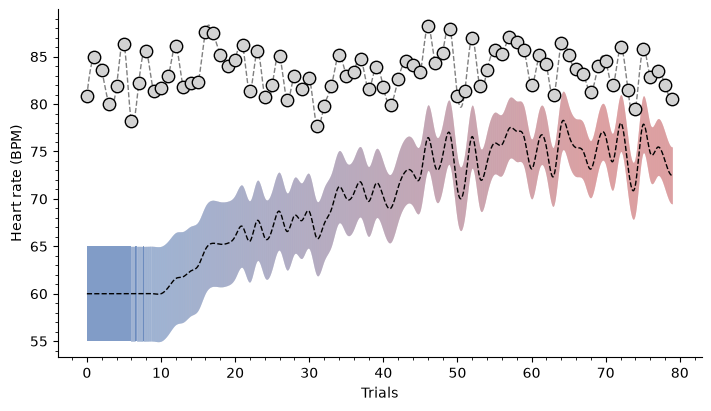

In [6]:
_, axs = plt.subplots(figsize=(7, 4))

# Heart rate
# ----------
axs.scatter(x, heart_rates + 8.0, s=80, color="lightgrey", edgecolor="k", zorder=10)
axs.plot(
    np.arange(0, n_trials - 1, 0.01),
    new_heart_rate + 8.0,
    color="grey",
    linestyle="--",
    linewidth=1,
)

# Cardiac beliefs
# ---------------
mu, pi = weighted_bayesian_update(
    mu_0=mu_bel,
    mu_1=heart_rates,
    pi_0=1 / sigma_bel**2,
    pi_1=np.array([1 / sigma_intero**2] * n_trials),
    omega=omegas,
)
f = interp1d(x, mu, kind="cubic")
new_mu = f(np.arange(0, n_trials - 1, 0.01))

f = interp1d(x, pi, kind="cubic")
new_pi = f(np.arange(0, n_trials - 1, 0.01))

f = interp1d(x, omegas, kind="linear")
new_omegas = f(np.arange(0, n_trials - 1, 0.01))

for i, omega in enumerate(new_omegas):
    color = cmap(omega)

    axs.fill_between(
        x=np.arange(0, n_trials - 1, 0.01)[i : i + 2],
        y1=(new_mu - np.sqrt(1 / new_pi))[i : i + 2],
        y2=(new_mu + np.sqrt(1 / new_pi))[i : i + 2],
        color=color,
        alpha=0.7,
        linewidth=0,
    )

axs.plot(
    np.arange(0, n_trials - 1, 0.01),
    new_mu,
    linestyle="--",
    linewidth=1,
    color="k",
)

axs.set(
    ylabel="Heart rate (BPM)",
)
axs.minorticks_on()

axs.set(xlabel="Trials")
sns.despine()
plt.savefig(Path().cwd().parent.parent / "figures" / "figure_1_illustration.svg")